# System Interface Tutorial (completo)

Este notebook muestra el flujo de trabajo más completo de `pryngles` usando la interfaz **`System`** para modelar curvas de luz en un sistema planeta + anillos, incorporando simultáneamente tres efectos fundamentales:

1. **Tránsito**: ocultación de la estrella por el planeta y sus anillos.
2. **Emisión térmica**: radiación del planeta según su distribución de temperatura.
3. **Polarización**: luz estelar reflejada y polarizada por dispersión en el sistema planeta–anillos.

---

# Entorno de ejecución

Si estás en Google Colab, instala `pryngles` y (opcionalmente) reinicia el runtime después de instalar dependencias pesadas.

- Instalación estable desde PyPI (recomendado):

In [1]:
#!pip install -Uq pryngles

- Última versión desde GitHub (si necesitas cambios no publicados en PyPI):

In [2]:
#!pip install -Uq git+https://github.com/seap-udea/pryngles.git

En todo caso, si ya cuenta con el paquete desde el source, actualice los modulos del paquete a través de un `git pull` command.

## 1. Importe de Librerias

In [3]:
import pryngles as pr

import numpy as np
import pandas as pd

# Orbital Geometry
import spiceypy as spy

In [4]:
# Set Plotting
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

from astropy.visualization import astropy_mpl_style

astropy_mpl_style['font.size'] = 8
astropy_mpl_style['figure.figsize'] = (12,6)

plt.style.use(astropy_mpl_style)

%matplotlib inline

In [5]:
# Recarga automática de módulos (útil durante desarrollo)
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


---

## 2. Parámetros del Sistema

Utilizaremos un sistema inspirado en **WASP-43b** (un Júpiter caliente bien caracterizado) pero con anillos añadidos para explorar su impacto en las observaciones.

In [6]:
# Parámetros del sistema WASP-43
system_params = {
    # Parámetros orbitales
    'period': 0.81347753,           # Período orbital [días]
    'a_abs': 0.01526,               # Semieje mayor absoluto [AU]
    'a': 4.857,                     # Semieje mayor [R_star]
    'inc': 90,                   # Inclinación orbital [grados]
    'ecc': 0.0,                     # Excentricidad
    'omega': 0.0,                   # Argumento del periastro [grados]
    
    # Parámetros estelares
    'M_star': 0.717,                # Masa estelar [M_sun]
    'R_star': 0.667,                # Radio estelar [R_sun]
    'T_star': 4520,                 # Temperatura efectiva estelar [K]
    
    # Parámetros planetarios
    'M_planet': 0,                  # Masa planetaria [M_jup] (No mass)
    'R_planet': 1.036,              # Radio planetario [R_jup]
    'T_day': 2000,                  # Temperatura lado diurno [K]
    'T_night': 1200,                 # Temperatura lado nocturno [K]
    'Delta_T': 800,                 # Diferencia de temperatura [K]
    'xi': 0.3,                      # Parámetro de desplazamiento del punto caliente y circulación atmosférica.
    
    # Parámetros de anillos (inspirados en Saturno, escalados)
    'R_in': 1.5,                    # Radio interno del anillo [R_planet]
    'R_out': 2.5,                   # Radio externo del anillo [R_planet]
    'ring_inc': 60,               # Inclinación del anillo respecto al orbital [grados]
    'ring_tau': 0.4,                # Profundidad óptica del anillo

    # Banda de observación (óptico-NIR)
    'lambda_min': 1.1e-6,           # Longitud de onda mínima [m]
    'lambda_max': 1.7e-6,           # Longitud de onda máxima [m]
}

### Conversión de Unidades

Pryngles utiliza un sistema de unidades interno. Convertimos los parámetros físicos a las unidades del sistema.

In [7]:
# Conversiones auxiliares
R_star_AU = system_params['a_abs'] / system_params['a']
R_sun_AU = pr.Consts.rsun / pr.Consts.au
R_star_m = R_star_AU * pr.Consts.au

# Masa estelar
M_star = system_params['M_star'] * pr.Consts.msun  # [kg]

# Masa planetaria
M_planet = system_params['M_planet'] * pr.Consts.mjupiter  # [kg]

# Radio planetario
R_planet = system_params['R_planet'] * pr.Consts.rjupiter  # [m]

print(f"\nConversiones a unidades SI:")
print(f"  Masa estelar: {M_star/pr.Consts.msun:.3f} M_sun = {M_star:.3e} m")
print(f"  Radio estelar: {R_star_m/pr.Consts.rsun:.3f} R_sun = {R_star_m:.3e} m")
print(f"  Radio planetario: {R_planet/R_star_m:.3f} R_star = {R_planet:.3e} m")


Conversiones a unidades SI:
  Masa estelar: 0.717 M_sun = 1.426e+30 m
  Radio estelar: 0.676 R_sun = 4.700e+08 m
  Radio planetario: 0.158 R_star = 7.407e+07 m


---

## 3. Construcción del Sistema con Pryngles

Utilizamos la clase `System` de pryngles para construir nuestro sistema planetario con anillos.

### 3.1 Inicialización del Sistema y la Estrella

In [8]:
# Crear el sistema
system = pr.System()

# Añadir la estrella central
star = system.add(
    kind="Star",
    m=M_star / system.um,              # Masa en unidades del sistema
    T_eff=system_params['T_star'],     # Temperatura efectiva [K]
    radius=R_star_m / system.ul,       # Radio en unidades del sistema
    limb_coeffs=[0.65],                # Limb Darkening Coefficients
)

print(f"Estrella añadida al sistema:")
print(f"  Nombre: {star.name}")
print(f"  Radio: {star.radius * system.ul / pr.Consts.rsun:.3f} R_sun")
print(f"  Temperatura: {star.T_eff:.0f} K")

Estrella añadida al sistema:
  Nombre: Star
  Radio: 0.676 R_sun
  Temperatura: 4520 K


### 3.2 Añadir el Planeta con Anillos

El planeta se configura con sus parámetros orbitales y físicos. Los anillos se definen mediante sus radios interno y externo, profundidad óptica y albedo.

In [9]:
# Añadir planeta con anillos
planet = system.add(
    kind="Planet",
    parent = star,
    m=M_planet / system.um,                      # Masa
    radius=R_planet / system.ul,                 # Radio planetario
    a=system_params['a_abs'],                    # Semieje mayor [AU]
    inc=pr.DEG*(90 - system_params['inc']),       # Inclinación orbital
    e=system_params['ecc'],                    # Excentricidad
    omega=pr.DEG*(system_params['omega']),        # Argumento del periastro
)

ring = system.add(
    kind = 'Ring',
    parent = planet,
    # Parámetros de los anillos
    fi=system_params['R_in'],               # Radio interno
    fe=system_params['R_out'],              # Radio externo
    i=pr.DEG*system_params['ring_inc'],     # Inclinación del anillo
    
    # Propiedades ópticas
    taur=system_params['ring_tau'],         # Profundidad óptica
)

print(f"\nPlaneta añadido:")
print(f"  Nombre: {planet.name}")
print(f"  Masa: {planet.m * system.um / pr.Consts.mjupiter:.3f} M_Jup")
print(f"  Radio: {planet.radius * system.ul / pr.Consts.rjupiter:.3f} R_Jup")
print(f"  Semieje mayor: {planet.a:.5f} AU")
print(f"  Inclinación: {pr.RAD*planet.inc:.1f}°\n")

print(f"Anillo añadido")
print(f"  R_in = {ring.fi} R_p, R_out = {ring.fe} R_p")
print(f"  Inclinación: {pr.RAD*ring.i:.2f}°")
print(f"  Profundidad óptica: {ring.taur}")


Planeta añadido:
  Nombre: Planet
  Masa: 0.000 M_Jup
  Radio: 1.036 R_Jup
  Semieje mayor: 0.01526 AU
  Inclinación: 0.0°

Anillo añadido
  R_in = 1.5 R_p, R_out = 2.5 R_p
  Inclinación: 60.00°
  Profundidad óptica: 0.4


### 3.3 Configuración del Observador

Definimos la orientación del observador. Para un tránsito primario, el observador se encuentra en el plano orbital mirando hacia el sistema.

In [10]:
# Usamos una matriz de rotación de Euler para orientar el sistema
system.n_obs = spy.eul2m(
    np.deg2rad(system_params['omega']),  # Ángulo 1
    np.deg2rad(system_params['inc']),    # Ángulo 2
    0,                                   # Ángulo 3
    3, 1, 3                              # Secuencia de ejes de rotación
)[0]

# Inicializar la simulación dinámica con Rebound
system.initialize_simulation()

# Discretizar el sistema
system.spangle_system()

print(f"Sistema dinámico inicializado: {system._simulated}")
print(f"Superficies discretizadas: {system._spangled}\n")
print(f"Vector observador (n_obs): {system.n_obs}")

Sistema dinámico inicializado: True
Superficies discretizadas: True

Vector observador (n_obs): [1. 0. 0.]


### 3.4 Visualización del Sistema

Visualizamos la configuración geométrica del sistema desde la perspectiva del observador.

(np.int64(0), np.int64(0))

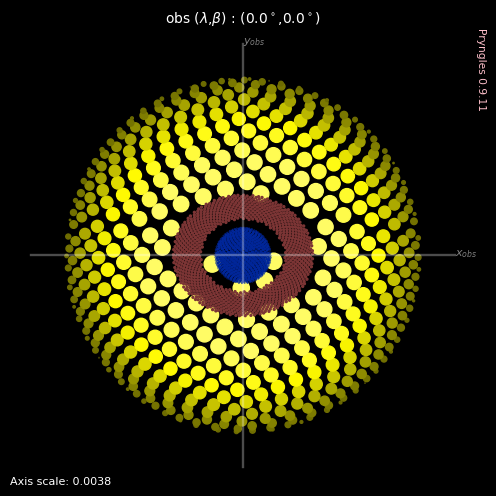

In [12]:
# Integrar a tiempo t=0 (tránsito primario)
system.integrate_perspective(0)

# Visualizar el sistema
system.sg.plot2d()

---

## 4. Modelos de Temperatura

Definimos modelos de distribución de temperatura para el planeta, necesario para el cálculo de emisión térmica.

### 4.1 Modelo de Temperatura Planetaria: Zhang & Showman

Este modelo parametriza la redistribución de calor en planetas fuertemente irradiados, con un punto caliente desplazado del punto subestelar debido a circulación atmosférica.

In [13]:
# Modelo de temperatura para el planeta
T_planet_model = {
    "type": "Zhang-Showman",
    "params": {
        "T_night": system_params['T_night'],      # Temperatura hemisferio nocturno [K]
        "Delta_T": system_params['Delta_T'],      # Diferencia día-noche [K]
        "xi_ratio": system_params['xi']           # Desplazamiento del punto caliente
    }
}

# Aplicar modelo de temperatura al planeta
planet.set_temperature_model(T_planet_model)

print("Modelo de temperatura Zhang & Showman aplicado al planeta:")
print(f"  T_noche = {system_params['T_night']} K")
print(f"  T_día = {system_params['T_night'] + system_params['Delta_T']} K")
print(f"  Desplazamiento del punto caliente: ξ = {system_params['xi']}")

Modelo de temperatura Zhang & Showman aplicado al planeta:
  T_noche = 1200 K
  T_día = 2000 K
  Desplazamiento del punto caliente: ξ = 0.3


---

## 5. Configuración del Detector

Definimos las propiedades del telescopio y detector que observará el sistema.

In [14]:
# Propiedades del detector/telescopio
DETECTOR_PROPERTIES = {
    # Banda espectral
    'wavelength_min': system_params['lambda_min'],  # [m]
    'wavelength_max': system_params['lambda_max'],  # [m]
    
    # Apertura del telescopio
    'apperture': 0.5,                                # [m] (50 cm de diámetro)
    
    # Eficiencia cuántica del detector
    'quantum_eff': 0.9,                             # 90% de eficiencia
    
    # Tiempo de cadencia (exposición)
    't_cadence': 15 * 60,                           # 10 minutos [s]
    
    # Distancia al sistema
    'distance': 100 * pr.Consts.pc                   # 100 parsecs [m]
}

print("Configuración del detector:")
print(f"  Banda: {DETECTOR_PROPERTIES['wavelength_min']*1e9:.0f} - {DETECTOR_PROPERTIES['wavelength_max']*1e9:.0f} nm")
print(f"  Apertura: {DETECTOR_PROPERTIES['apperture']*100:.0f} cm")
print(f"  Eficiencia cuántica: {DETECTOR_PROPERTIES['quantum_eff']*100:.0f}%")
print(f"  Cadencia: {DETECTOR_PROPERTIES['t_cadence']/60:.0f} minutos")
print(f"  Distancia al sistema: {DETECTOR_PROPERTIES['distance']/pr.Consts.pc:.1f} pc")

Configuración del detector:
  Banda: 1100 - 1700 nm
  Apertura: 50 cm
  Eficiencia cuántica: 90%
  Cadencia: 15 minutos
  Distancia al sistema: 100.0 pc


---

## 6. Cálculo de la Curva de Luz Completa

Calculamos la curva de luz a lo largo de un período orbital completo.

In [15]:
# Número de puntos temporales
n_times = 150

# Tiempos de integración: un período orbital centrado en el tránsito
times_days = np.linspace(
    -system_params['period'] / 2,
    system_params['period'] / 2,
    n_times
)  # [días]

# Convertir a unidades del sistema
times_system = times_days * pr.Consts.day / system.ut  # [unidades de tiempo del sistema]

print(f"  Número de puntos: {n_times}")
print(f"  Rango: {times_days[0]:.3f} a {times_days[-1]:.3f} días")
print(f"  Paso temporal: {(times_days[1] - times_days[0]) * 24 * 60:.2f} minutos")

  Número de puntos: 150
  Rango: -0.407 a 0.407 días
  Paso temporal: 7.86 minutos


### 6.1 Cómputo de la Curva de Luz con Todos los Efectos

Utilizamos el método `compute_lightcurve` de pryngles para calcular simultáneamente:
- **transit**: Atenuación por ocultación del disco estelar
- **emission**: Flujo térmico del planeta
- **polarization**: Fracción de luz reflejada/dispersada y polarizada por anillos y atmosferas

El atributo `system.lightcurve` contiene el resultado completo del cálculo de la curva de luz del sistema para una serie de tiempos dados y, opcionalmente, una señal sintética de observación. Así mismo se incluyen los modelos de efectos calculados y las contribuciones para cada uno de los cuerpos

---

#### Items del diccionario

- **`times`** (`np.ndarray`)  
  Arreglo unidimensional de tiempos en los que se evaluó la curva de luz.  
  Los valores están expresados en las unidades internas del sistema dinámico.

- **`flux`** (`np.ndarray`)  
  Flujo total normalizado del sistema en cada tiempo.  
  Incluye la contribución combinada de todos los efectos físicos seleccionados
  (tránsito, emisión, polarización, etc.).  
  El flujo estelar no perturbado está normalizado a 1.

- **`model`** (`pandas.DataFrame`)
  Modelo detallado de la curva de luz con columnas de índice múltiple (`MultiIndex`):  
  - Nivel 0: nombre del cuerpo (`body`)  
  - Nivel 1: efecto físico (`effect`)  
  Contiene las contribuciones individuales de cada cuerpo y cada efecto físico antes
  de ser combinadas en el flujo total.
  Los modelos se definen a partir de los efectos solicitados `["reflection", "transit", "emission", "polarization"]`

- **`effects`** (`list`)  
  Tupla con los nombres de los efectos físicos incluidos en el cálculo de la curva de luz.  
  Ejemplo: `["transit", "emission", "polarization"]`.

- **`bodies`** (`list`)  
  Lista con los nombres de los cuerpos considerados en el cálculo de la curva de luz.  
  Por defecto, incluye todos los cuerpos no estelares del sistema.

- **`observer`** (`dict`)  
  Diccionario que describe la geometría del observador utilizada en el cálculo:  
  - **`n_obs`** (`np.array`): vector unitario que define la dirección del observador en el sistema de referencia del modelo.  
  - **`direction`** (`np.array`): dirección del observador expresada en coordenadas angulares (grados), típicamente longitud y latitud eclíptica.

- **`bandwidth`** (`tuple`)  
  Rango espectral `(λ_min, λ_max)` en metros utilizado para integrar la emisión térmica.  
  Solo es relevante si el efecto de emisión está incluido en `effects`.

- **`signal`** (`dict`, opcional)  
  Presente únicamente si se solicitó la simulación de señal instrumental: 
  - **`times`** (`np.array`): tiempos de observación por el instrumento en segundos.
  - **`signal_flux`** (`np.array`): flujo total observado simulado, incluyendo ruido instrumental.  
  - **`signal_error`** (`np.array`): incertidumbre asociada a cada punto del flujo simulado.


**Nota:** Podrá visualizar el tiempo de computo. Tenga en consideración que se han calculado efectos simultaneos y además, se ha incluido la generación de señal sintética. Para eficiencia en el calculo se recomienda calcular un efecto a la vez.

In [18]:
print("Calculando curva de luz completa...\n")

# Calcular curva de luz con los tres efectos

# Transit and Signal
system.compute_lightcurve(
    times=times_system,
    effects=['transit'],
    signal=DETECTOR_PROPERTIES
)

transit_flux = system.lightcurve['transit']

print(f"  Tránsito - Profundidad máxima: {(-transit_flux.sum(axis = 1).min()):.3f}")

# Emission
system.compute_lightcurve(
    times=times_system,
    bandwidth=(system_params['lambda_min'], system_params['lambda_max']),
    effects=['emission']
)

emission_flux = system.lightcurve['emission']

print(f"  Emisión térmica - Flujo máximo: {emission_flux.sum(axis = 1).max()*1e6:.2e} ppm")

# Polarization
system.compute_lightcurve(
    times=times_system,
    effects=['polarization']
)

polarized_flux = system.lightcurve['scattering']
polarized_degree = system.lightcurve['polarization']

print(f"  Polarización - Grado máximo: {polarized_degree.sum(axis = 1).max():.4f}%")

# TOTAL FLUX
total_flux = 1 + transit_flux.sum(axis = 1) + emission_flux.sum(axis = 1) + polarized_flux.sum(axis = 1)

print("\n✓ Curva de luz calculada exitosamente.")
print("\nResultados almacenados en system.lightcurve\n")
print(f"Atributos disponibles: {list(system.lightcurve.keys())}")

Calculando curva de luz completa...



Computing Lightcurve : 100%|██████████| 150/150 [00:33<00:00,  4.45it/s]


  Tránsito - Profundidad máxima: -0.000


Computing Lightcurve : 100%|██████████| 150/150 [00:35<00:00,  4.24it/s]


  Emisión térmica - Flujo máximo: 5.49e+02 ppm


Computing Lightcurve : 100%|██████████| 150/150 [02:52<00:00,  1.15s/it]

  Polarización - Grado máximo: 0.4071%

✓ Curva de luz calculada exitosamente.

Resultados almacenados en system.lightcurve

Atributos disponibles: ['times', 'total_flux', 'effects', 'bodies', 'observer', 'bandwidth', 'polarization', 'scattering']


In [24]:
print("Calculando curva de luz completa...\n")

# Calcular curva de luz con los tres efectos

# Transit and Signal
system.compute_lightcurve(
    times=times_system,
    effects=['transit'],
    signal=DETECTOR_PROPERTIES
)

transit_flux = system.lightcurve['transit']

print(f"  Tránsito - Profundidad máxima: {(-transit_flux.sum(axis = 1).min()):.3f}")

Calculando curva de luz completa...



Computing Lightcurve : 100%|██████████| 150/150 [00:30<00:00,  4.98it/s]

  Tránsito - Profundidad máxima: 0.137


### 6.2 Generación de señal sintética

Previamente se definió la creación de un detector del sistema dentro del atributo `system.detector`. Ahora, con base en el flujo total, generaremos la señal sintética de observación a través del método `Detector.generate_signal()`. Este método retorna los siguientes atributos del objeto `Detector`

- **`times`** (`np.ndarray`)  
  Arreglo unidimensional de tiempos en los que se evaluó la señal de lacurva de luz.  
  Los valores están expresados en segundos.

- **`signal_flux`** (`np.ndarray`)  
  Flujo total normalizado observado del sistema en cada tiempo.

- **`signal_error`** (`np.ndarray`)  
  Variación estocástica de ruido de captura del flujo total normalizado observado del sistema en cada tiempo.

In [25]:
signal_times, signal_flux, signal_error = system.detector.generate_signal(times_system*system.ut, total_flux)

---

## 7. Visualización de Resultados

### 7.1 Curva de Luz de Tránsito

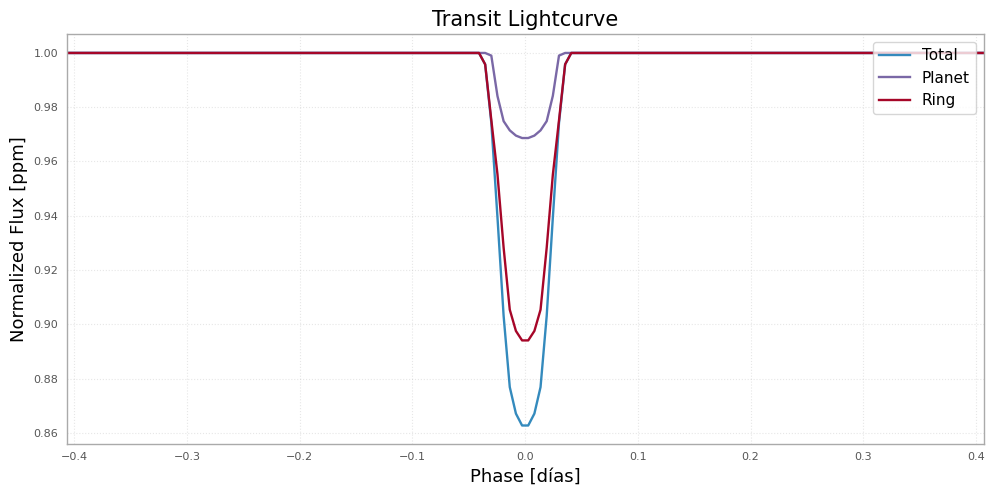

In [26]:
fig, ax = plt.subplots(figsize=(10, 5))

# Profundidad de tránsito
ax.plot(times_days, 1 + transit_flux.sum(axis = 1), label='Total')

ax.plot(times_days, 1 + transit_flux['Planet'], label = 'Planet')
ax.plot(times_days, 1 + transit_flux['Ring'], label = 'Ring')

ax.set_xlabel('Phase [días]', fontsize=13)
ax.set_ylabel('Normalized Flux [ppm]', fontsize=13)
ax.set_title('Transit Lightcurve', fontsize=15)
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, alpha=0.3, linestyle=':')
ax.set_xlim(times_days[0], times_days[-1])

plt.tight_layout()
plt.show()

### 7.2 Curva de Emisión Térmica

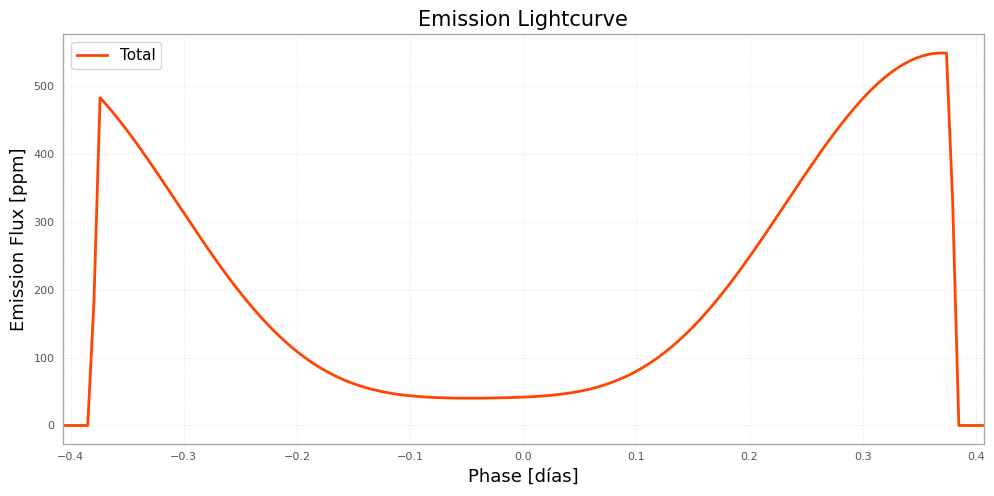

In [27]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(times_days, emission_flux.sum(axis = 1) * 1e6, color='orangered', linewidth=2, label='Total')

ax.set_xlabel('Phase [días]', fontsize=13)
ax.set_ylabel('Emission Flux [ppm]', fontsize=13)
ax.set_title('Emission Lightcurve', fontsize=15)
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3, linestyle=':')
ax.set_xlim(times_days[0], times_days[-1])

plt.tight_layout()
plt.show()

### 7.3 Curva de Polarización

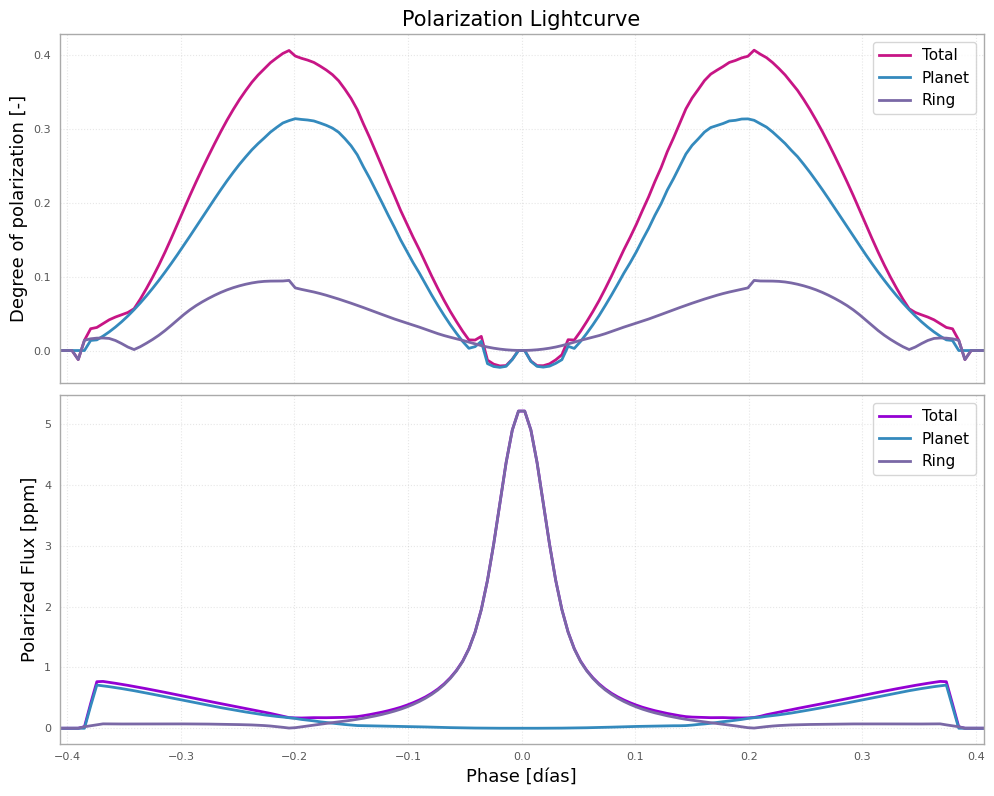

In [28]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Panel superior: Grado de polarización
ax1.plot(times_days, polarized_degree.sum(axis = 1), color='mediumvioletred', linewidth=2, label='Total')

ax1.plot(times_days, polarized_degree['Planet'], linewidth=2, label='Planet')
ax1.plot(times_days, polarized_degree['Ring'], linewidth=2, label='Ring')

ax1.set_ylabel('Degree of polarization [-]', fontsize=13)
ax1.set_title('Polarization Lightcurve', fontsize=15)
ax1.legend(fontsize=11, loc='upper right')
ax1.grid(True, alpha=0.3, linestyle=':')

# Panel inferior: Flujo polarizado
ax2.plot(times_days, polarized_flux.sum(axis = 1)*1e6, color='darkviolet', linewidth=2, label='Total')

ax2.plot(times_days, polarized_flux['Planet']*1e6, linewidth=2, label='Planet')
ax2.plot(times_days, polarized_flux['Ring']*1e6, linewidth=2, label='Ring')

ax2.set_xlabel('Phase [días]', fontsize=13)
ax2.set_ylabel('Polarized Flux [ppm]', fontsize=13)
ax2.legend(fontsize=11, loc='upper right')
ax2.grid(True, alpha=0.3, linestyle=':')
ax2.set_xlim(times_days[0], times_days[-1])

plt.tight_layout()
plt.show()

### 7.4 Curva de luz completa y señal de observación

Visualización integrada de los tres efectos fotométricos junto con la generación sintética de la señal de la curva de luz.

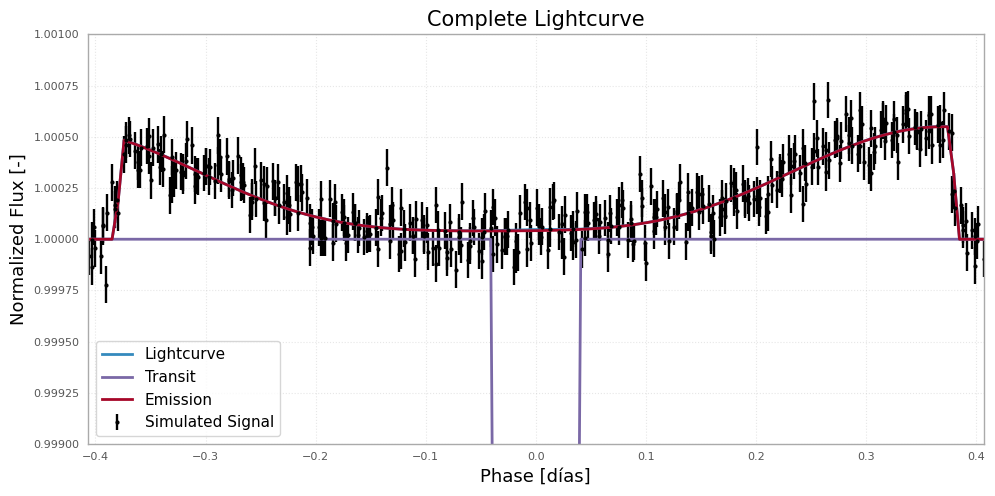

In [29]:
fig, ax = plt.subplots(figsize=(10, 5))

# Signal
ax.errorbar(signal_times/pr.Consts.days, signal_flux, 
            yerr = signal_error, markersize = 2, fmt = 'o',
            label = 'Simulated Signal', color = 'black', alpha=1)

ax.plot(times_days, total_flux, color='C0', linewidth=2, label='Lightcurve')
ax.plot(times_days, 1 + transit_flux.sum(axis = 1), color='C1', linewidth=2, label='Transit')
ax.plot(times_days, 1 + emission_flux.sum(axis = 1), color='C2', linewidth=2, label='Emission')

ax.set_xlabel('Phase [días]', fontsize=13)
ax.set_ylabel('Normalized Flux [-]', fontsize=13)
ax.set_title('Complete Lightcurve', fontsize=15)
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3, linestyle=':')
ax.set_xlim(times_days[0], times_days[-1])
ax.set_ylim(0.999,1.001)

plt.tight_layout()
plt.show()

---

##  Resumen

Este notebook ha implementado el uso de `pryngles` para modelar simultáneamente:

1. **Curvas de luz de tránsito** de planetas con anillos
2. **Emisión térmica** considerando distribuciones de temperatura realistas en el planeta. Aún no se consideran los efectos por presencia de anillos
3. **Señales polarimétricas** de luz reflejada y dispersada por superficies atmosféricas y anillos.

### Referencias y Documentación

- **Pryngles Repositori**: [https://github.com/seap-udea/pryngles](https://github.com/seap-udea/pryngles)
- **Pryngles API**: [ReadTheDocs](https://pryngles.readthedocs.io/en/latest/)

---

**Autor**: Sebastián Numpaque

**Version**: pryngles 0.9.11

**Fecha**: 04/02/2026